# OpenMC transport model for a concentric annular fuel model (i.e like Missouri Research Reactor)

This notebook mirrors the workflow in frm2_nat.ipynb, but replaces the involute fuel plates with a manufacturable concentric annular layout. We should export some cells to reusable python scripts so the notebooks are easier to read and more modular.

## Models

The reference case below uses five concentric fuel annuli with 3.5 mm fuel thickness. That combination stays close to the involute notebook's fuel loading while removing the involute manufacturability constraint.

In [119]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

import concentric_fuel
import reactor_geometry
from ploting import resolve_openmc_exec

importlib.reload(concentric_fuel)
importlib.reload(reactor_geometry)

from concentric_fuel import (
    ConcentricElementParameters,
    build_parameter_report,
    quick_layout_plot,
    validate_parameters,
 )
from reactor_geometry import ReactorTankParameters, build_reactor_model, validate_reactor_tanks

CONCENTRIC_FUEL_PARAMETERS = ConcentricElementParameters(
    ring_count=7,
    ring_thickness_cm=0.5,
    coolant_gap_cm=7.0,
    inner_radius_cm=4.5,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    # d2o_tank_radius_cm=499.0,
    d2o_tank_radius_cm=250.0,
    h2o_tank_radius_cm=500.0,
    # h_d2o_tank_cm=990.0,
    h_d2o_tank_cm=600.0,
    h_h2o_tank_cm=1000.0,
 )

validate_parameters(CONCENTRIC_FUEL_PARAMETERS)
validate_reactor_tanks(CONCENTRIC_FUEL_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(CONCENTRIC_FUEL_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

BUILD_DIR = Path("build") / "notebook" / "concentric"
PREVIEW_DIR = BUILD_DIR / "preview"
RUN_DIR = BUILD_DIR / "reactor_run"
for build_path in (BUILD_DIR, PREVIEW_DIR, RUN_DIR):
    build_path.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(CONCENTRIC_FUEL_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'ring_count': 7,
  'ring_thickness_cm': 0.5,
  'coolant_gap_cm': 7.0,
  'inner_radius_cm': 4.5,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'radial_span_cm': 45.5,
  'edge_gap_cm': 0.0,
  'h_total_cm': 400.0,
  'first_ring_inner_radius_cm': 4.5,
  'last_ring_outer_radius_cm': 50.0,
  'uranium_area_fraction': 0.07692307692307693,
  'uranium_volume_cm3': 179777.6396016759,
  'uranium_mass_kg': 2193.287203140446},
 'reactor_tanks': {'d2o_tank_radius_cm': 250.0,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600.0,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

In [120]:
def estimate_particles_per_mesh_bin(particles, batches, inactive, mesh_shape):
    active_batches = max(0, batches - inactive)
    mesh_bins = mesh_shape[0] * mesh_shape[1]
    if mesh_bins <= 0 or active_batches <= 0:
        return 0.0
    return particles * active_batches / mesh_bins


def build_model(
    rod_insertion=0.0,
    particles=12000,
    batches=100,
    inactive=20,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
 ):
    rod_insertion = float(np.clip(rod_insertion, 0.0, 1.0))
    model, metadata = build_reactor_model(
        CONCENTRIC_FUEL_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=rod_insertion,
    )

    total_half = 0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm
    active_half = 0.5 * CONCENTRIC_FUEL_PARAMETERS.h_active_cm

    source = openmc.IndependentSource(
        space=openmc.stats.CylindricalIndependent(
            r=openmc.stats.PowerLaw(
                CONCENTRIC_FUEL_PARAMETERS.inner_radius_cm,
                CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
                1.0,
            ),
            phi=openmc.stats.Uniform(0.0, 2.0 * np.pi),
            z=openmc.stats.Uniform(-active_half, active_half),
        ),
        constraints={"fissionable": True},
    )

    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles = particles
    settings.batches = batches
    settings.inactive = inactive
    settings.source = source
    settings.source_rejection_fraction = 0.01
    settings.temperature = {"method": "interpolation"}
    model.settings = settings

    tallies = []

    if global_mesh_shape is not None:
        global_mesh = openmc.RegularMesh()
        global_mesh.dimension = (global_mesh_shape[0], 1, global_mesh_shape[1])
        global_mesh.lower_left = (-REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, -1.0, -total_half)
        global_mesh.upper_right = (REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm, 1.0, total_half)

        global_tally = openmc.Tally(name="global-mesh")
        global_tally.filters = [openmc.MeshFilter(global_mesh)]
        global_tally.scores = ["flux", "fission", "nu-fission"]
        tallies.append(global_tally)
        metadata["global_mesh_shape"] = tuple(global_mesh.dimension)
        metadata["global_mesh_histories_per_bin"] = estimate_particles_per_mesh_bin(
            particles, batches, inactive, global_mesh_shape
        )

    if fuel_mesh_shape is not None:
        fuel_mesh = openmc.RegularMesh()
        fuel_mesh.dimension = (fuel_mesh_shape[0], 1, fuel_mesh_shape[1])
        fuel_mesh.lower_left = (
            -CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
            -1.0,
            -0.5 * CONCENTRIC_FUEL_PARAMETERS.h_active_cm,
        )
        fuel_mesh.upper_right = (
            CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
            1.0,
            0.5 * CONCENTRIC_FUEL_PARAMETERS.h_active_cm,
        )

        fuel_tally = openmc.Tally(name="fuel-mesh")
        fuel_tally.filters = [openmc.MeshFilter(fuel_mesh)]
        fuel_tally.scores = ["flux", "fission", "nu-fission"]
        tallies.append(fuel_tally)
        metadata["fuel_mesh_shape"] = tuple(fuel_mesh.dimension)
        metadata["fuel_mesh_histories_per_bin"] = estimate_particles_per_mesh_bin(
            particles, batches, inactive, fuel_mesh_shape
        )

    if tallies:
        model.tallies = openmc.Tallies(tallies)

    metadata["tally_names"] = [tally.name for tally in tallies]
    metadata["particles"] = particles
    metadata["batches"] = batches
    metadata["inactive"] = inactive
    return model, metadata

{'ring_count': 7, 'ring_thickness_cm': 0.5, 'coolant_gap_cm': 7.0, 'inner_radius_cm': 4.5, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'radial_span_cm': 45.5, 'edge_gap_cm': 0.0, 'h_total_cm': 400.0, 'first_ring_inner_radius_cm': 4.5, 'last_ring_outer_radius_cm': 50.0, 'uranium_area_fraction': 0.07692307692307693, 'uranium_volume_cm3': 179777.6396016759, 'uranium_mass_kg': 2193.287203140446}


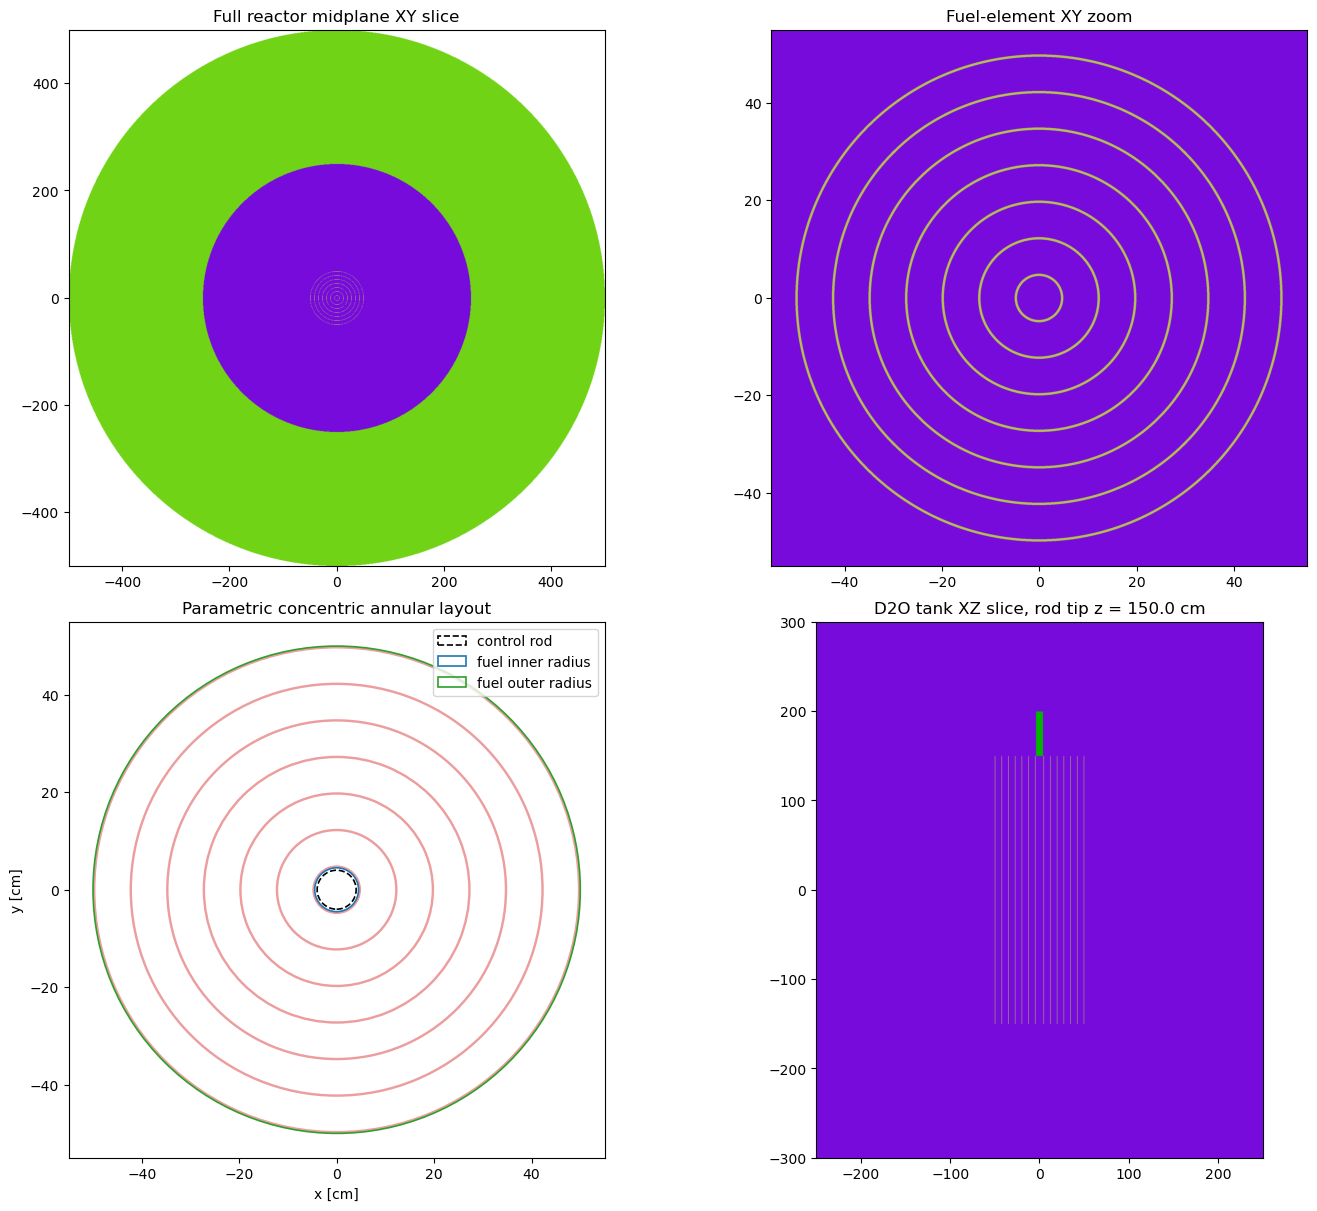

In [121]:
preview_model, preview_metadata = build_model(
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
        2.0 * REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(1200, 1200),
    axes=axes[0, 0],
)
axes[0, 0].set_title("Full reactor midplane XY slice")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.2 * CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
        2.2 * CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
    ),
    basis="xy",
    color_by="material",
    pixels=(2200, 2200),
    axes=axes[0, 1],
)
axes[0, 1].set_title("Fuel-element XY zoom")

quick_layout_plot(CONCENTRIC_FUEL_PARAMETERS, ax=axes[1, 0])
axes[1, 0].set_title("Parametric concentric annular layout")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(
        2.0 * REACTOR_TANK_PARAMETERS.d2o_tank_radius_cm,
        REACTOR_TANK_PARAMETERS.h_d2o_tank_cm,
    ),
    basis="xz",
    color_by="material",
    pixels=(1800, 1600),
    axes=axes[1, 1],
)
axes[1, 1].set_title(
    f"D2O tank XZ slice, rod tip z = {preview_metadata['fuel_element']['rod_tip_z_cm']:.1f} cm"
 )

print(build_parameter_report(CONCENTRIC_FUEL_PARAMETERS))
plt.show()

In [122]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_model(
        rod_insertion=reference_insertion,
        particles=12000,
        batches=5,
        inactive=1,
        global_mesh_shape=None,
        fuel_mesh_shape=None,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Plotting Tallies

This plotting cell stays dormant unless the run above was executed with mesh tallies enabled by passing a non-None mesh shape to build_model.

In [123]:
from matplotlib.colors import LogNorm

if statepoint_path is None or reference_metadata is None:
    print("Run the previous cell after configuring OpenMC nuclear data to get k_eff and optional flux or fission maps.")
else:
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
        print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
        print(f"reactivity = {rho_pcm:.1f} pcm")

        tally_names = reference_metadata.get("tally_names", [])
        if not tally_names:
            print(
                "This run was executed without mesh tallies for speed. Rebuild with global_mesh_shape or fuel_mesh_shape to plot maps."
            )
        else:
            tally_name = "global-mesh" if "global-mesh" in tally_names else tally_names[0]
            mesh_tally = statepoint.get_tally(name=tally_name)
            flux_tally = mesh_tally.get_slice(scores=["flux"])
            fission_tally = mesh_tally.get_slice(scores=["fission"])

            mesh_dimension = tuple(mesh_tally.filters[0].mesh.dimension)
            flux = flux_tally.get_reshaped_data(value="mean").reshape(mesh_dimension).squeeze()
            fission = fission_tally.get_reshaped_data(value="mean").reshape(mesh_dimension).squeeze()
            flux_std = flux_tally.get_reshaped_data(value="std_dev").reshape(mesh_dimension).squeeze()
            fission_std = fission_tally.get_reshaped_data(value="std_dev").reshape(mesh_dimension).squeeze()

            flux_masked = np.ma.masked_less_equal(flux, 0.0)
            fission_masked = np.ma.masked_less_equal(fission, 0.0)
            flux_rel_err = np.ma.masked_where((flux <= 0.0) | ~np.isfinite(flux_std), flux_std / flux)
            fission_rel_err = np.ma.masked_where(
                (fission <= 0.0) | ~np.isfinite(fission_std), fission_std / fission
            )

            positive_flux = np.asarray(flux[flux > 0.0])
            positive_fission = np.asarray(fission[fission > 0.0])

            if tally_name == "fuel-mesh":
                extent = [
                    -CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
                    CONCENTRIC_FUEL_PARAMETERS.outer_radius_cm,
                    -0.5 * CONCENTRIC_FUEL_PARAMETERS.h_active_cm,
                    0.5 * CONCENTRIC_FUEL_PARAMETERS.h_active_cm,
                ]
                histories_per_bin = reference_metadata.get("fuel_mesh_histories_per_bin")
            else:
                extent = [
                    -REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
                    REACTOR_TANK_PARAMETERS.h2o_tank_radius_cm,
                    -0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
                    0.5 * REACTOR_TANK_PARAMETERS.h_h2o_tank_cm,
                ]
                histories_per_bin = reference_metadata.get("global_mesh_histories_per_bin")

            print(f"{tally_name} histories per bin: {histories_per_bin:.3f}")
            print(f"flux nonzero fraction: {(flux > 0.0).mean():.3f}")
            print(f"fission nonzero fraction: {(fission > 0.0).mean():.3f}")
            if histories_per_bin is not None and histories_per_bin < 10.0:
                print(
                    "This mesh is strongly under-sampled. Increase active batches and particles, or reduce the mesh size for a readable map."
                )

            fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

            flux_norm = LogNorm(
                vmin=max(np.percentile(positive_flux, 5), positive_flux.min()),
                vmax=positive_flux.max(),
            )
            fission_norm = LogNorm(
                vmin=max(np.percentile(positive_fission, 5), positive_fission.min()),
                vmax=positive_fission.max(),
            )

            flux_image = axes[0, 0].imshow(
                flux_masked.T,
                origin="lower",
                aspect="auto",
                extent=extent,
                norm=flux_norm,
                cmap="viridis",
            )
            axes[0, 0].set_xlabel("x [cm]")
            axes[0, 0].set_ylabel("z [cm]")
            axes[0, 0].set_title(f"Flux score ({tally_name}, log scale)")
            plt.colorbar(flux_image, ax=axes[0, 0], label="flux")

            fission_image = axes[0, 1].imshow(
                fission_masked.T,
                origin="lower",
                aspect="auto",
                extent=extent,
                norm=fission_norm,
                cmap="magma",
            )
            axes[0, 1].set_xlabel("x [cm]")
            axes[0, 1].set_ylabel("z [cm]")
            axes[0, 1].set_title(f"Fission score ({tally_name}, log scale)")
            plt.colorbar(fission_image, ax=axes[0, 1], label="fission")

            flux_rel_err_finite = np.asarray(flux_rel_err.filled(np.nan))
            flux_rel_err_finite = flux_rel_err_finite[np.isfinite(flux_rel_err_finite)]
            fission_rel_err_finite = np.asarray(fission_rel_err.filled(np.nan))
            fission_rel_err_finite = fission_rel_err_finite[np.isfinite(fission_rel_err_finite)]

            if flux_rel_err_finite.size == 0 or fission_rel_err_finite.size == 0:
                axes[1, 0].axis("off")
                axes[1, 1].axis("off")
                axes[1, 0].text(
                    0.5,
                    0.5,
                    "Relative error is unavailable with only one active batch.",
                    ha="center",
                    va="center",
                    wrap=True,
                )
                axes[1, 1].text(
                    0.5,
                    0.5,
                    "Run more active batches to estimate tally uncertainty.",
                    ha="center",
                    va="center",
                    wrap=True,
                )
            else:
                flux_err_image = axes[1, 0].imshow(
                    flux_rel_err.T,
                    origin="lower",
                    aspect="auto",
                    extent=extent,
                    vmin=0.0,
                    vmax=min(2.0, float(np.percentile(flux_rel_err_finite, 95))),
                    cmap="cividis",
                )
                axes[1, 0].set_xlabel("x [cm]")
                axes[1, 0].set_ylabel("z [cm]")
                axes[1, 0].set_title("Flux relative error")
                plt.colorbar(flux_err_image, ax=axes[1, 0], label="std. dev. / mean")

                fission_err_image = axes[1, 1].imshow(
                    fission_rel_err.T,
                    origin="lower",
                    aspect="auto",
                    extent=extent,
                    vmin=0.0,
                    vmax=min(2.0, float(np.percentile(fission_rel_err_finite, 95))),
                    cmap="cividis",
                )
                axes[1, 1].set_xlabel("x [cm]")
                axes[1, 1].set_ylabel("z [cm]")
                axes[1, 1].set_title("Fission relative error")
                plt.colorbar(fission_err_image, ax=axes[1, 1], label="std. dev. / mean")

            plt.show()

k_eff = 1.008371 +/- 0.006192
reactivity = 830.2 pcm
This run was executed without mesh tallies for speed. Rebuild with global_mesh_shape or fuel_mesh_shape to plot maps.
